# ***Time series forecasting model using Long Short-Term Memory (LSTM) neural networks***

In [ ]:
#Implement a time series forecasting model using Long Short-Term Memory (LSTM) neural networks. You will work with the Air Passengers dataset, which contains monthly totals of international airline passengers from 1949 to 1960.The dataset is provided below.

In [ ]:
pip install pandas numpy matplotlib scikit-learn tensorflow


# Step 1: Import necessary **libraries**

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


In [12]:
pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


# **Step 2: Load the Air Passengers dataset**

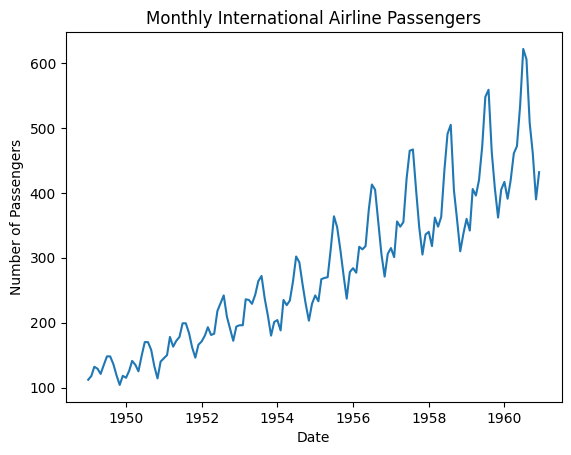

In [3]:

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
plt.plot(df)
plt.title('Monthly International Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.show()


# **Step 3: Normalize the data**

In [4]:

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values.reshape(-1, 1))


# **Step 4: Create time series sequences**

In [5]:

def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 12
X, y = create_dataset(scaled_data, time_step)

# Reshape input to [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)


In [6]:
# Step 5: Split into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# **Step 6: Build the LSTM model**

In [7]:

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **Step 7: Train the model**

In [8]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0736 - val_loss: 0.0346
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0131 - val_loss: 0.0224
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0117 - val_loss: 0.0478
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0147 - val_loss: 0.0304
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0088 - val_loss: 0.0226
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0078 - val_loss: 0.0216
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0069 - val_loss: 0.0225
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0084 - val_loss: 0.0218
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0068 - val_loss: 0.0235
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0066 - val_loss: 0.0216
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0066 - val_loss: 0.0215
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0061 - val_l

# **Step 8: Plot training history**

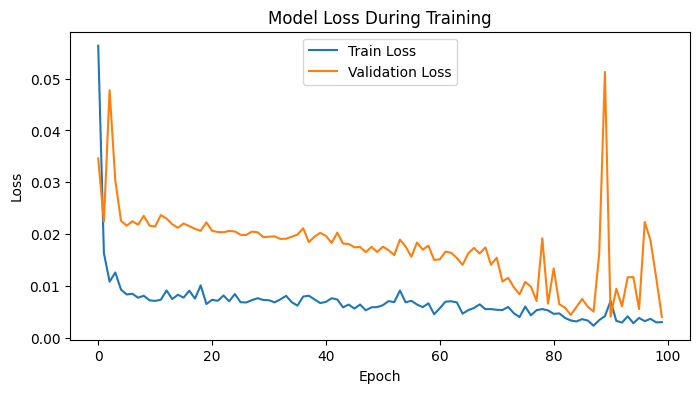

In [9]:

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# **Step 6: Plot Historical + Forecasted Data**

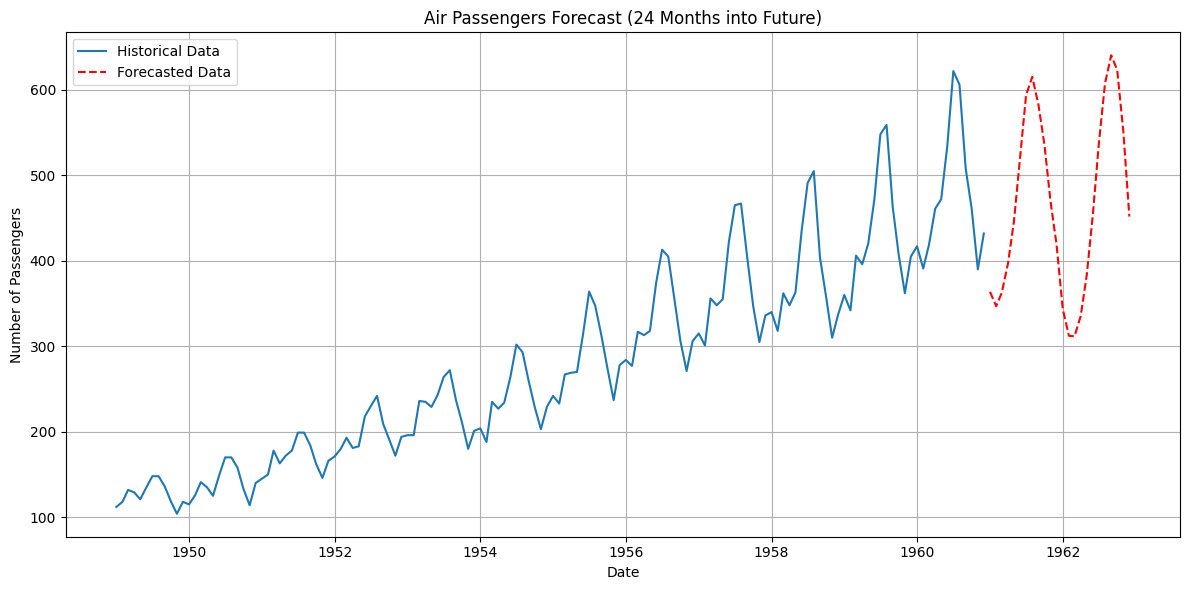

In [11]:
future_steps = 24
input_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
future_predictions = []
for _ in range(future_steps):
    next_val = model.predict(input_sequence, verbose=0)
    future_predictions.append(next_val[0, 0])

    # Reshape prediction and update input sequence
    next_val_reshaped = next_val.reshape(1, 1, 1)
    input_sequence = np.concatenate((input_sequence[:, 1:, :], next_val_reshaped), axis=1)


# Convert predictions back to original scale
future_predictions_inv = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')

future_df = pd.DataFrame(future_predictions_inv, index=future_dates, columns=['Forecasted Passengers'])
plt.figure(figsize=(12, 6))
plt.plot(df, label='Historical Data')
plt.plot(future_df, color='red', linestyle='--', label='Forecasted Data')
plt.title('Air Passengers Forecast (24 Months into Future)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
future_df.to_csv('future_air_passengers_forecast.csv')
